<a href="https://colab.research.google.com/github/amatra-m/mnist-robustness-analysis/blob/main/MNIST_Robustness_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Robustness and Failure Analysis of a Neural Network on MNIST


### Objective

This project builds a neural network for handwritten digit recognition using the MNIST dataset.

Rather than evaluating the model only using accuracy, this project also investigates:

- Which handwritten digits are most commonly confused
- How confident the model is when making incorrect predictions
- How image noise affects classification performance
- How image rotation affects model performance
- Whether modifying the neural network architecture improves performance and robustness

## Research Questions

This project investigates the following questions:

1. How accurately can a simple neural network classify handwritten digits?
2. Which digits are most frequently confused with each other?
3. Can the neural network make incorrect predictions with high confidence?
4. How does image noise affect classification accuracy?
5. How does image rotation affect classification accuracy?
6. Does increasing the complexity of the neural network improve its performance?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 1. Dataset Understanding

### What is MNIST?

MNIST is a dataset of handwritten digits ranging from 0 to 9.

Each image is a grayscale image with dimensions **28 × 28 pixels**.

Therefore, each image contains:

28 × 28 = **784 pixel values**

The dataset contains **10 classes**, corresponding to the digits:

0, 1, 2, 3, 4, 5, 6, 7, 8 and 9.

The label associated with each image represents the actual digit shown in that image.

In [ ]:
# Load the MNIST dataset

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [ ]:
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


In [ ]:
print("First image:")
print(x_train[0])

print("\nActual label:", y_train[0])

First image:
[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 2

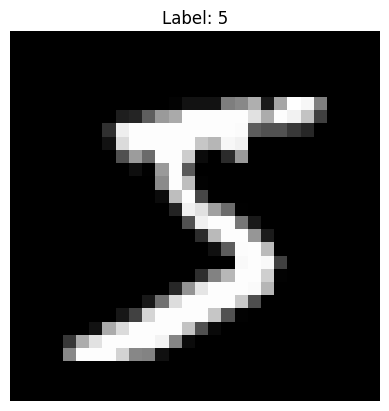

In [ ]:
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()

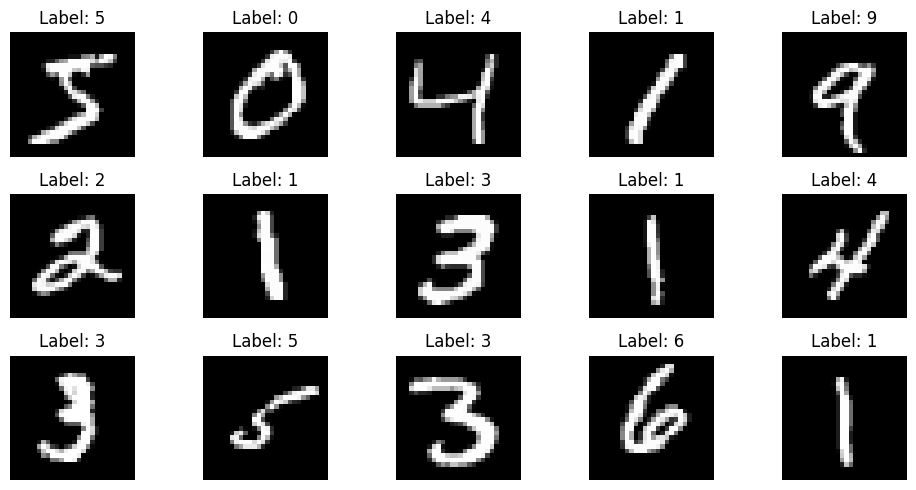

In [ ]:
plt.figure(figsize=(10, 5))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Count how many training images belong to each digit

unique, counts = np.unique(y_train, return_counts=True)

for digit, count in zip(unique, counts):
    print(f"Digit {digit}: {count} images")

Digit 0: 5923 images
Digit 1: 6742 images
Digit 2: 5958 images
Digit 3: 6131 images
Digit 4: 5842 images
Digit 5: 5421 images
Digit 6: 5918 images
Digit 7: 6265 images
Digit 8: 5851 images
Digit 9: 5949 images


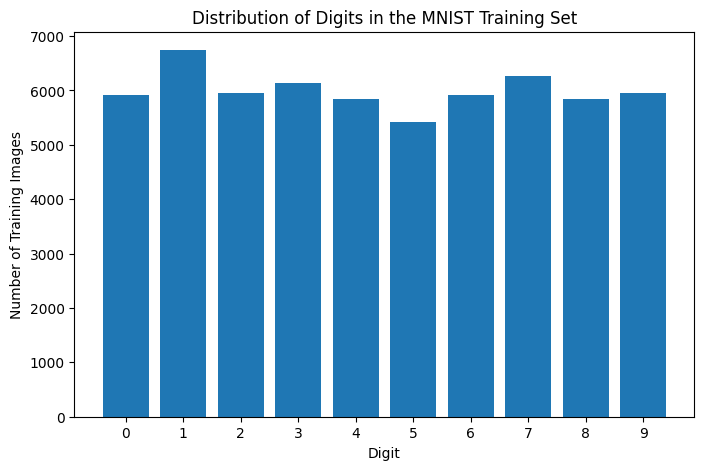

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(unique, counts)

plt.xlabel("Digit")
plt.ylabel("Number of Training Images")
plt.title("Distribution of Digits in the MNIST Training Set")
plt.xticks(range(10))

plt.show()

### Observation

The MNIST training dataset contains examples from all ten digit classes.

The class distribution is reasonably balanced, with no single digit overwhelmingly dominating the dataset. This is useful because severe class imbalance could bias the model toward predicting the most common classes more often.

## 2. Data Preprocessing

The pixel values in MNIST range from 0 to 255.

To make training more stable and efficient, the pixel values are normalized to a range of 0 to 1 by dividing every value by 255.

Normalization ensures that the neural network works with smaller and consistently scaled numerical values.

In [ ]:
# Check the pixel value range before normalization

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0
Maximum pixel value: 255


In [ ]:
# Normalize pixel values from 0-255 to 0-1

x_train_normalized = x_train.astype("float32") / 255.0
x_test_normalized = x_test.astype("float32") / 255.0

In [ ]:
print("Before normalization:")
print("Min:", x_train.min())
print("Max:", x_train.max())

print("\nAfter normalization:")
print("Min:", x_train_normalized.min())
print("Max:", x_train_normalized.max())

Before normalization:
Min: 0
Max: 255

After normalization:
Min: 0.0
Max: 1.0


In [ ]:
print("Training label examples:", y_train[:15])
print("Unique labels:", np.unique(y_train))

Training label examples: [5 0 4 1 9 2 1 3 1 4 3 5 3 6 1]
Unique labels: [0 1 2 3 4 5 6 7 8 9]


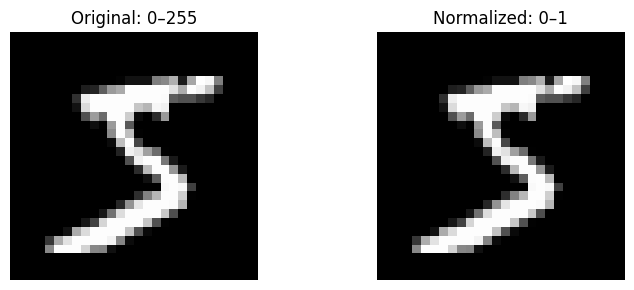

In [ ]:
plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.imshow(x_train[0], cmap="gray")
plt.title("Original: 0–255")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(x_train_normalized[0], cmap="gray")
plt.title("Normalized: 0–1")
plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

The original and normalized images look visually identical. Normalization only changes the numerical pixel range from 0–255 to 0–1, which helps the neural network train more effectively.

## 3. Baseline Neural Network

A simple feed-forward neural network is used as the baseline model.

The architecture contains:

- A `Flatten` layer to convert each 28 × 28 image into a 784-value vector
- A hidden `Dense` layer with 128 neurons and ReLU activation
- An output `Dense` layer with 10 neurons and Softmax activation

The 10 output neurons correspond to the digits 0–9.

In [ ]:
baseline_model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

### Activation Functions

**ReLU** is used in the hidden layer because it introduces non-linearity into the network and is computationally efficient.

Without an activation function, multiple neural network layers would behave similarly to a single linear transformation.

**Softmax** is used in the output layer because this is a multi-class classification problem. It converts the final outputs into probabilities for the ten digit classes, with the probabilities summing to approximately 1.

In [ ]:
baseline_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_baseline = baseline_model.fit(
    x_train_normalized,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9221 - loss: 0.2725 - val_accuracy: 0.9650 - val_loss: 0.1246
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9645 - loss: 0.1195 - val_accuracy: 0.9750 - val_loss: 0.0909
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9748 - loss: 0.0819 - val_accuracy: 0.9750 - val_loss: 0.0856
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9806 - loss: 0.0615 - val_accuracy: 0.9758 - val_loss: 0.0788
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9856 - loss: 0.0482 - val_accuracy: 0.9777 - val_loss: 0.0758
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9890 - loss: 0.0365 - val_accuracy: 0.9735 - val_loss: 0.0958
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9906 - loss: 0.0305 - val_accuracy: 0.9788 - val_loss: 0.0795
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9925 - loss: 0.0244 - 

## 4. Training Performance

The training and validation accuracy and loss are plotted across epochs to understand how the model learns and to check for possible overfitting.

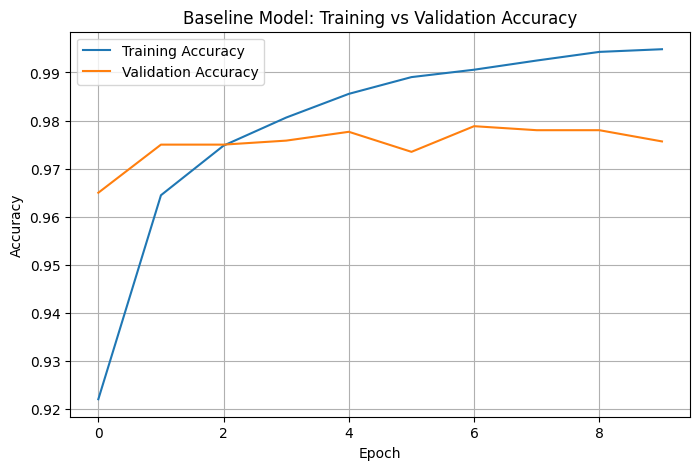

In [ ]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history_baseline.history["accuracy"], label="Training Accuracy")
plt.plot(history_baseline.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline Model: Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

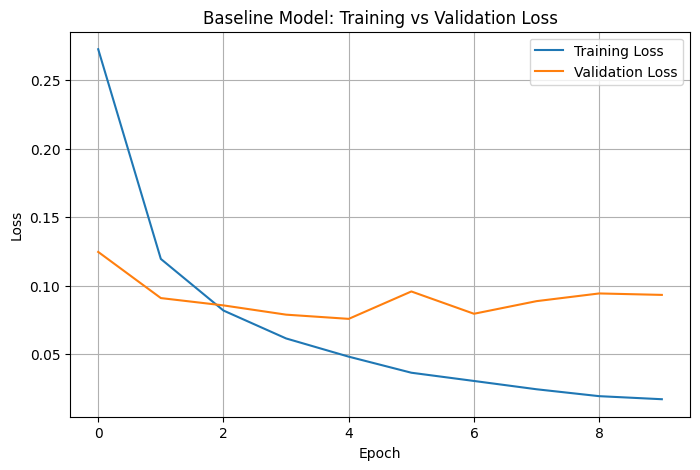

In [ ]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history_baseline.history["loss"], label="Training Loss")
plt.plot(history_baseline.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline Model: Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

### Observation

The baseline model learns quickly, with training accuracy reaching approximately 99%.

Validation accuracy remains around 97–98%, showing that the model generalizes well to unseen data.

However, after several epochs, training loss continues to decrease while validation loss begins to fluctuate and increase slightly. This indicates mild overfitting, where the model continues improving on the training data without achieving the same improvement on validation data.

This suggests that increasing the number of training epochs alone may not improve generalization.

In [ ]:
test_loss_baseline, test_accuracy_baseline = baseline_model.evaluate(
    x_test_normalized,
    y_test,
    verbose=0
)

print(f"Baseline Test Accuracy: {test_accuracy_baseline:.4f}")
print(f"Baseline Test Loss: {test_loss_baseline:.4f}")

Baseline Test Accuracy: 0.9770
Baseline Test Loss: 0.0805


## 5. Model Evaluation and Error Analysis

Accuracy gives an overall measure of model performance, but it does not show which digits are difficult to distinguish.

A confusion matrix allows us to examine which digit classes are being predicted correctly and which classes are being confused with one another.

In [ ]:
# Generate predictions for the test set

y_pred_probabilities = baseline_model.predict(
    x_test_normalized,
    verbose=0
)

# Convert probability predictions into digit predictions
y_pred = np.argmax(y_pred_probabilities, axis=1)

print("Predictions generated successfully.")
print("First 20 predictions:", y_pred[:20])
print("First 20 actual labels:", y_test[:20])

Predictions generated successfully.
First 20 predictions: [7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4]
First 20 actual labels: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


In [ ]:
# Create the confusion matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 964    1    2    0    1    1    3    0    3    5]
 [   0 1127    4    0    0    1    2    0    1    0]
 [   2    1 1016    4    1    0    0    5    2    1]
 [   0    1    9  985    0    1    0    5    3    6]
 [   1    0    4    1  953    0    2    1    3   17]
 [   1    0    0   12    1  867    6    1    2    2]
 [   3    2    3    0    4    4  939    1    2    0]
 [   1    4   14    0    0    0    0 1005    2    2]
 [   2    1    5    6    3    3    0    6  944    4]
 [   0    5    1    6   11    7    1    6    2  970]]


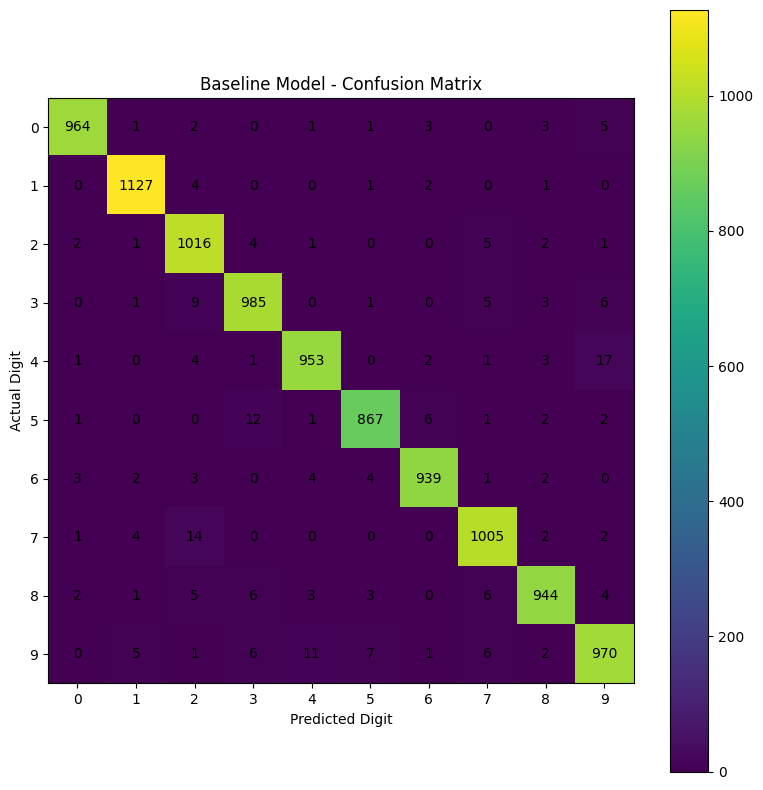

In [ ]:
plt.figure(figsize=(8, 8))

plt.imshow(cm)

plt.title("Baseline Model - Confusion Matrix")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")

plt.xticks(range(10))
plt.yticks(range(10))

# Add the numbers inside each cell
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
# Find the most common confusion between two different digits

cm_without_diagonal = cm.copy()
np.fill_diagonal(cm_without_diagonal, 0)

most_confused_index = np.unravel_index(
    np.argmax(cm_without_diagonal),
    cm_without_diagonal.shape
)

actual_digit = most_confused_index[0]
predicted_digit = most_confused_index[1]
confusion_count = cm_without_diagonal[most_confused_index]

print(
    f"The most common confusion is: "
    f"{actual_digit} → {predicted_digit}"
)
print(f"Number of such errors: {confusion_count}")

The most common confusion is: 4 → 9
Number of such errors: 17


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.98      0.97      1032
           3       0.97      0.98      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.98      0.97      0.98       892
           6       0.99      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.97      0.97       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



## 6. Misclassification Detective

Overall accuracy does not tell us what the model gets wrong.

To investigate the model's failure cases, we identify incorrectly classified images and examine both the actual label and the model's predicted label and confidence.

In [ ]:
# Find incorrectly classified images

incorrect_indices = np.where(y_pred != y_test)[0]

print("Total incorrect predictions:", len(incorrect_indices))

Total incorrect predictions: 230


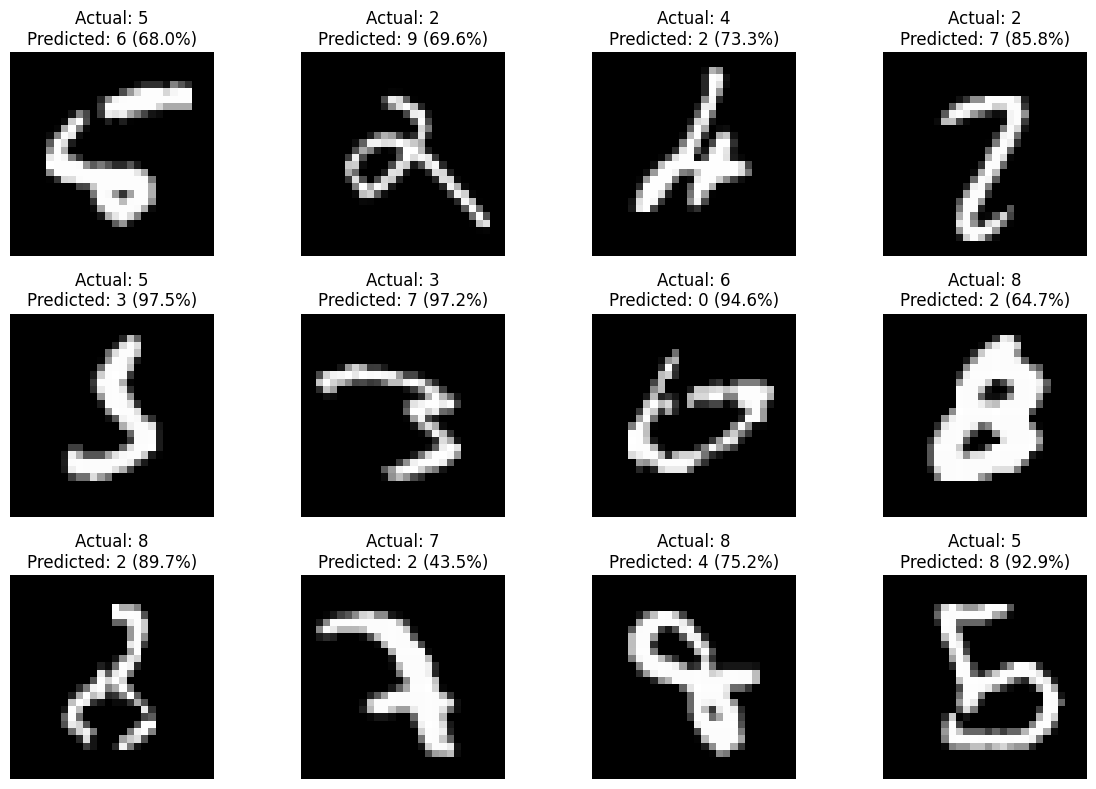

In [ ]:
plt.figure(figsize=(12, 8))

for i, index in enumerate(incorrect_indices[:12]):
    plt.subplot(3, 4, i + 1)

    plt.imshow(x_test[index], cmap="gray")

    predicted_digit = y_pred[index]
    actual_digit = y_test[index]
    confidence = np.max(y_pred_probabilities[index])

    plt.title(
        f"Actual: {actual_digit}\n"
        f"Predicted: {predicted_digit} ({confidence:.1%})"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Can the Model Be Confidently Wrong?

A particularly interesting failure case occurs when the model assigns a high probability to an incorrect prediction.

To investigate this, we identify the incorrectly classified test images for which the model had the highest confidence.

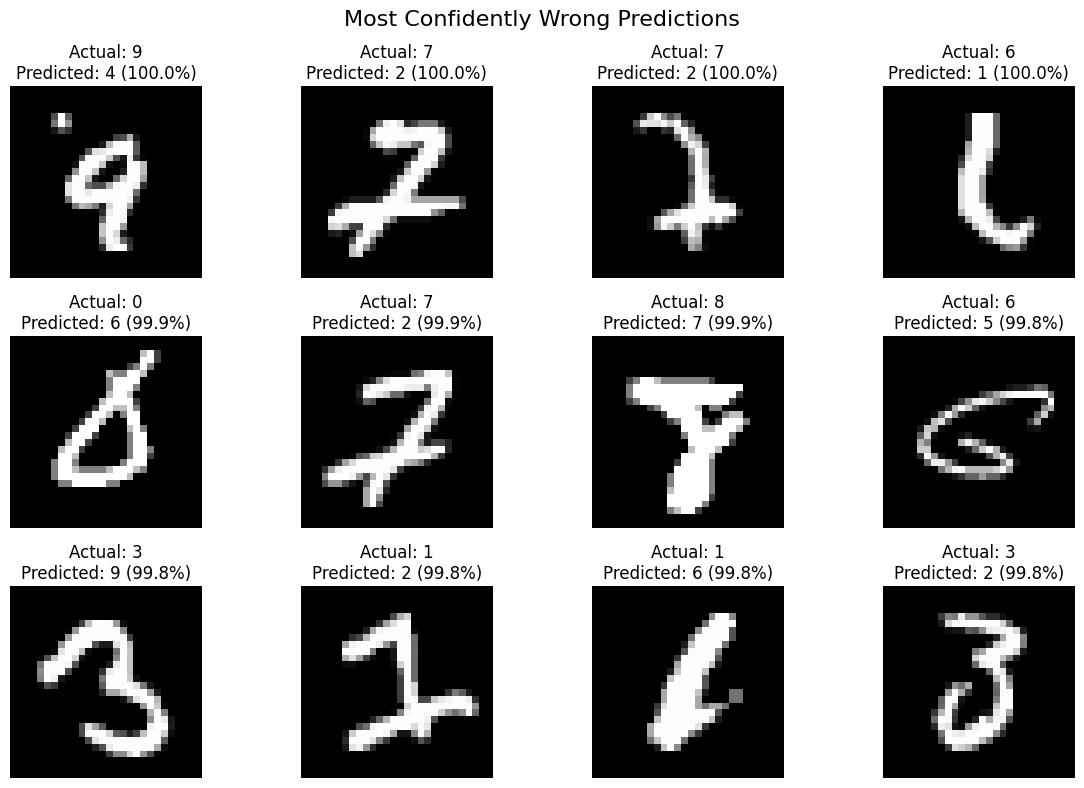

In [ ]:
# Find the most confidently wrong predictions

incorrect_confidences = np.max(
    y_pred_probabilities[incorrect_indices],
    axis=1
)

# Sort incorrect predictions from highest to lowest confidence
sorted_positions = np.argsort(incorrect_confidences)[::-1]

top_confident_errors = incorrect_indices[sorted_positions[:12]]

plt.figure(figsize=(12, 8))

for i, index in enumerate(top_confident_errors):
    plt.subplot(3, 4, i + 1)

    actual = y_test[index]
    predicted = y_pred[index]
    confidence = np.max(y_pred_probabilities[index])

    plt.imshow(x_test[index], cmap="gray")

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted} ({confidence:.1%})"
    )

    plt.axis("off")

plt.suptitle(
    "Most Confidently Wrong Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Key Finding

The error analysis revealed that some incorrect predictions were made with extremely high confidence. Several misclassified images received displayed confidence values of 99.8%–100%.

This shows that high softmax confidence does not necessarily imply that a prediction is correct. Therefore, overall accuracy alone is not sufficient to understand the reliability of a neural network.

This motivates further investigation into how the model behaves under changes to the input, such as noise and rotation.

## 8. Model B — Deeper Neural Network

To investigate whether a more expressive architecture improves classification performance, a second neural network is created with two hidden layers.

### Architecture

Input: 28 × 28 image

↓ Flatten

784 features

↓ Dense + ReLU

256 neurons

↓ Dense + ReLU

128 neurons

↓ Dense + Softmax

10 digit classes

The baseline model contained one hidden layer with 128 neurons, while Model B contains two hidden layers with 256 and 128 neurons.

In [ ]:
model_b = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation="relu"),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model_b.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_b.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_model_b = model_b.fit(
    x_train_normalized,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9339 - loss: 0.2211 - val_accuracy: 0.9680 - val_loss: 0.1085
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9726 - loss: 0.0890 - val_accuracy: 0.9788 - val_loss: 0.0721
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9808 - loss: 0.0601 - val_accuracy: 0.9728 - val_loss: 0.0837
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9856 - loss: 0.0460 - val_accuracy: 0.9767 - val_loss: 0.0884
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9881 - loss: 0.0365 - val_accuracy: 0.9787 - val_loss: 0.0732
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9906 - loss: 0.0278 - val_accuracy: 0.9772 - val_loss: 0.0927
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9922 - loss: 0.0235 - val_accuracy: 0.9753 - val_loss: 0.1020
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9920 - loss: 0.0239 -

In [ ]:
test_loss_b, test_accuracy_b = model_b.evaluate(
    x_test_normalized,
    y_test,
    verbose=0
)

print(f"Baseline Test Accuracy: {test_accuracy_baseline:.4f}")
print(f"Model B Test Accuracy:  {test_accuracy_b:.4f}")

print(f"\nBaseline Test Loss: {test_loss_baseline:.4f}")
print(f"Model B Test Loss:  {test_loss_b:.4f}")

Baseline Test Accuracy: 0.9770
Model B Test Accuracy:  0.9778

Baseline Test Loss: 0.0805
Model B Test Loss:  0.0985


In [ ]:
accuracy_change = test_accuracy_b - test_accuracy_baseline

print(f"Accuracy change: {accuracy_change:+.4f}")
print(f"Accuracy change: {accuracy_change * 100:+.2f} percentage points")

Accuracy change: +0.0008
Accuracy change: +0.08 percentage points


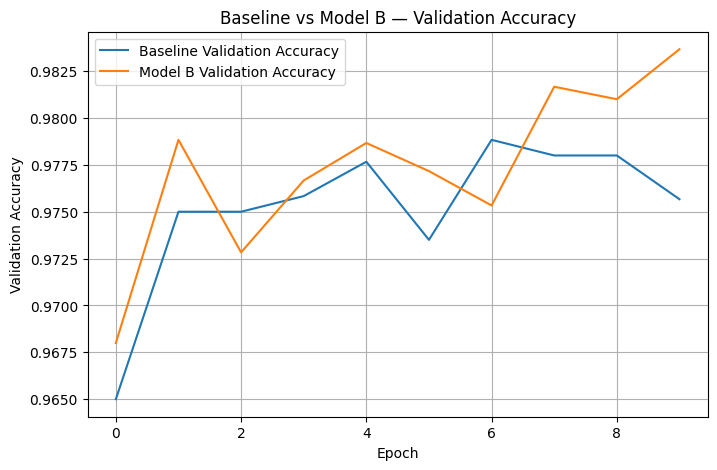

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history["val_accuracy"],
    label="Baseline Validation Accuracy"
)

plt.plot(
    history_model_b.history["val_accuracy"],
    label="Model B Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Baseline vs Model B — Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

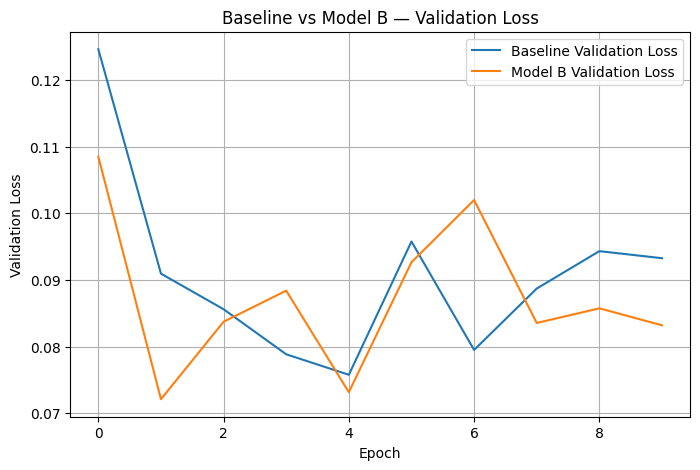

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_baseline.history["val_loss"],
    label="Baseline Validation Loss"
)

plt.plot(
    history_model_b.history["val_loss"],
    label="Model B Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Baseline vs Model B — Validation Loss")
plt.legend()
plt.grid(True)

plt.show()